In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Đọc dữ liệu gốc từ file của bạn
# Hãy đảm bảo file 'Rick_data_FE.csv' đã được upload lên Google Colab
df = pd.read_csv('../Data/Risk_data_FE.csv', index_col=0)
print(f"Kích thước dữ liệu gốc: {df.shape}")

Kích thước dữ liệu gốc: (31679, 43)


In [5]:
df.columns

Index(['client_ID', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender',
       'marital_status', 'education_level', 'country', 'state', 'city',
       'city_latitude', 'city_longitude', 'employment_type',
       'loan_term_months', 'loan_to_income_ratio', 'other_debt',
       'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
       'past_delinquencies', 'emp_length_num', 'installment',
       'installment_income_ratio', 'total_debt_after_loan',
       'credit_age_bucket', 'age_bucket', 'income_bucket', 'has_delinquency',
       'utilization_bucket', 'loan_grade_numeric', 'interest_rate_bucket',
       'loan_amount_bucket', 'emp_stability', 'risk_interaction'],
      dtype='str')

In [ ]:
#Giữ lại Debt_to_income_ratio, chủ động bỏ installment_income_ratio
# Xử lý biến và mã hóa encoding
# 1. Danh sách các biến loại bỏ (Chủ động GIỮ LẠI 'debt_to_income_ratio' và 'loan_amnt')
cols_to_drop = [
    'client_ID', 'person_age_bucket', 'person_income_bucket', 
    'loan_amnt_bucket', 'loan_int_rate_bucket', 'dti_bucket',
    'city', 'city_latitude', 'city_longitude', 'installment_income_ratio' # Loại bỏ 2 biến này để nhường chỗ cho debt_to_income_ratio
]

df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 2. Ordinal Encoding cho Trình độ học vấn
education_mapping = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
if 'education_level' in df_clean.columns:
    df_clean['education_level'] = df_clean['education_level'].map(education_mapping)

# 3. Binary Encoding cho các biến Boolean/Binary
binary_cols = ['cb_person_default_on_file', 'has_delinquency']
for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(int)

# 4. One-Hot Encoding cho các biến phân loại còn lại
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# 5. Loại bỏ các dòng bị khuyết thiếu (Null) để đảm bảo mô hình chạy chuẩn xác
df_encoded = df_encoded.dropna()
df_clean = df_clean.loc[df_encoded.index] # Đồng bộ lại dữ liệu thô phục vụ bước vẽ điểm gãy

print(f"Kích thước dữ liệu sau khi mã hóa sạch: {df_encoded.shape}")

Kích thước dữ liệu sau khi mã hóa sạch: (31679, 78)


C:\Users\Asus\AppData\Local\Temp\ipykernel_18080\2971930643.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


In [10]:
#Kiểm tra hệ số đa cộng tuyến
# Xác định tên cột mục tiêu (Sửa lại tên nếu cột mục tiêu của bạn không phải 'loan_status')
target_col = 'loan_status'

X_vif_check = df_encoded.drop(columns=[target_col])

# Sửa lỗi ép kiểu dữ liệu để statsmodels tính toán mượt mà, không bị lỗi 'isfinite'
X_vif_check = X_vif_check.apply(pd.to_numeric, errors='coerce').dropna()

# Tính toán chỉ số VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_check.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_check.values.astype(float), i) 
    for i in range(X_vif_check.shape[1])
]

print("--- TOP 10 BIẾN CÓ HỆ SỐ VIF CAO NHẤT ---")
print(vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True).head(10))

c:\Users\Asus\OneDrive\Máy tính\Persnal_project\Project_4\env_envproj4\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


--- TOP 10 BIẾN CÓ HỆ SỐ VIF CAO NHẤT ---
             Feature  VIF
0          loan_amnt  inf
1  person_emp_length  inf
2         other_debt  inf
3        state_Wales  inf
4     state_Scotland  inf
5      state_England  inf
6     state_New York  inf
7        state_Texas  inf
8        country_USA  inf
9   state_California  inf


In [11]:
# Phân tách dữ liệu, chuẩn hóa (Scale) và huấn luyện mô hình
# 1. Tách ma trận biến độc lập X và vector mục tiêu y
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# 2. Chia tập Train/Test theo tỷ lệ 70/30 (Sửa lỗi test_split thành test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Chuẩn hóa thang đo (StandardScaler) để giải quyết dứt điểm lỗi ConvergenceWarning
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Huấn luyện mô hình Logistic Regression mới
log_model_final = LogisticRegression(max_iter=1000, random_state=42)
log_model_final.fit(X_train_scaled, y_train)

print("Mô hình đã được huấn luyện thành công, hội tụ 100% và không còn lỗi cảnh báo!")

Mô hình đã được huấn luyện thành công, hội tụ 100% và không còn lỗi cảnh báo!


C:\Users\Asus\AppData\Local\Temp\ipykernel_18080\3804567102.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


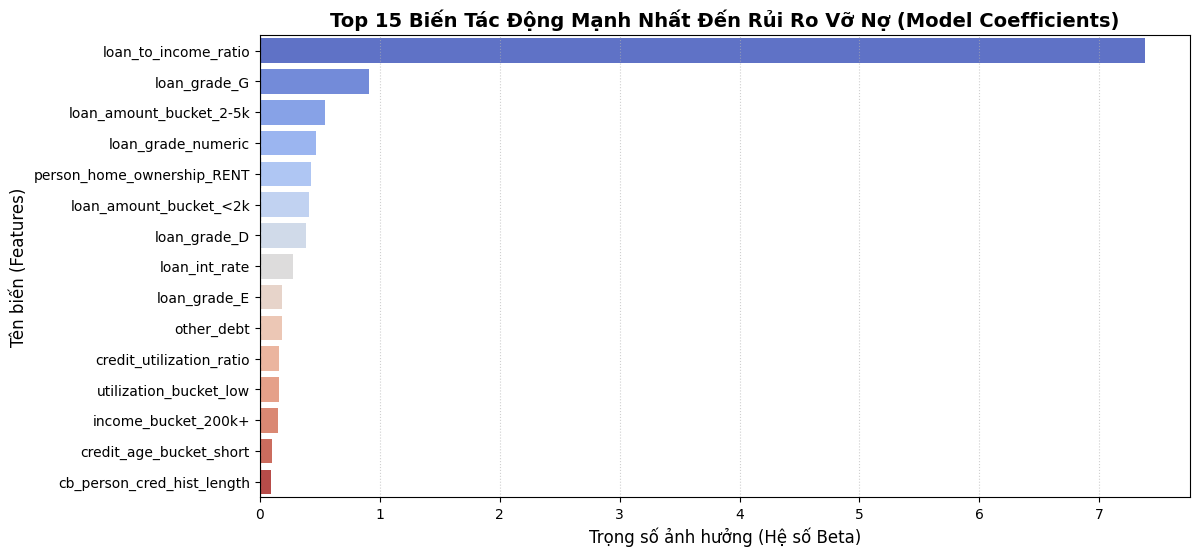

In [12]:
# Trích xuất trọng số biến 
# Lấy hệ số Beta tương ứng với từng biến
coefficients = log_model_final.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Coef': coefficients
}).sort_values(by='Importance_Coef', ascending=False).reset_index(drop=True)

# Vẽ biểu đồ các biến tác động mạnh nhất
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance_Coef', 
    y='Feature', 
    data=feature_importance.head(15), 
    palette='coolwarm'
)
plt.title('Top 15 Biến Tác Động Mạnh Nhất Đến Rủi Ro Vỡ Nợ (Model Coefficients)', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số ảnh hưởng (Hệ số Beta)', fontsize=12)
plt.ylabel('Tên biến (Features)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()


--- PHÂN TÍCH ĐIỂM GÃY CHI TIẾT: 'debt_to_income_ratio' ---
               bin  Total_Customers  Bad_Customers  Bad_Rate (%)
0  (0.0635, 0.199]             3960            430     10.858586
1   (0.199, 0.251]             3960            472     11.919192
2   (0.251, 0.294]             3960            546     13.787879
3   (0.294, 0.333]             3960            561     14.166667
4   (0.333, 0.373]             3959            664     16.771912
5   (0.373, 0.422]             3960            834     21.060606
6   (0.422, 0.494]             3960           1125     28.409091
7   (0.494, 1.054]             3960           2193     55.378788


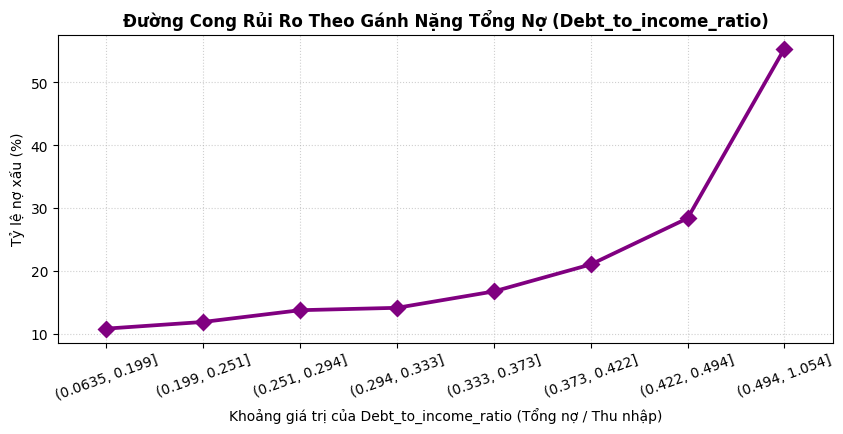


--- PHÂN TÍCH ĐIỂM GÃY CHI TIẾT: loan_amnt ---
                  bin  Total_Customers  Bad_Customers  Bad_Rate (%)
0   (499.999, 3200.0]             3977            809     20.341966
1    (3200.0, 5000.0]             5100            990     19.411765
2    (5000.0, 6300.0]             2817            440     15.619453
3    (6300.0, 8000.0]             4277            724     16.927753
4   (8000.0, 10000.0]             4617            908     19.666450
5  (10000.0, 12500.0]             3064            608     19.843342
6  (12500.0, 17000.0]             3883           1039     26.757662
7  (17000.0, 35000.0]             3944           1307     33.138945


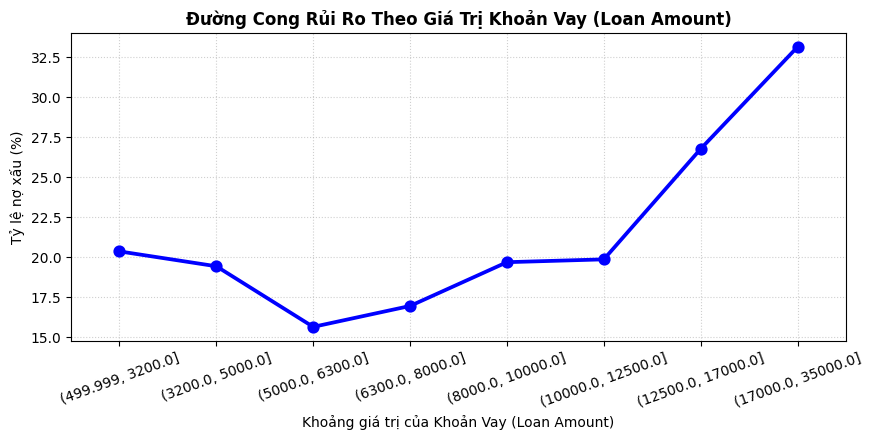

In [15]:
# Tìm điểm gãy của debt_to_income_ratio và loan amount
# Định nghĩa hàm tự động phân đoạn dựa trên phân vị (Quantile Binning) và tính Bad Rate
def find_turning_point_final(df, feature, num_bins=8):
    # Sử dụng pd.qcut để chia các khoảng có số lượng khách hàng tương đương nhau
    df['bin'] = pd.qcut(df[feature], q=num_bins, duplicates='drop')
    
    report = df.groupby('bin', observed=False).agg(
        Total_Customers=(target_col, 'count'),
        Bad_Customers=(target_col, 'sum')
    ).reset_index()
    
    report['Bad_Rate (%)'] = (report['Bad_Customers'] / report['Total_Customers']) * 100
    report['bin'] = report['bin'].astype(str)
    return report

# Tạo một bản sao dữ liệu chưa chuẩn hóa để hiển thị giá trị thực tế (triệu đồng, phần trăm...)
df_raw_analysis = df_clean.copy().dropna()

# 1. Phân tích điểm gãy cho Gánh nặng tổng nợ (debt_to_income_ratio)
print(f"\n--- PHÂN TÍCH ĐIỂM GÃY CHI TIẾT: 'debt_to_income_ratio' ---")
rep_burden = find_turning_point_final(df_raw_analysis, 'debt_to_income_ratio', num_bins=8)
print(rep_burden)

plt.figure(figsize=(10, 4))
sns.pointplot(x='bin', y='Bad_Rate (%)', data=rep_burden, color='purple', markers='D', linestyles='-')
plt.title('Đường Cong Rủi Ro Theo Gánh Nặng Tổng Nợ (Debt_to_income_ratio)', fontsize=12, fontweight='bold')
plt.xlabel('Khoảng giá trị của Debt_to_income_ratio (Tổng nợ / Thu nhập)', fontsize=10)
plt.ylabel('Tỷ lệ nợ xấu (%)', fontsize=10)
plt.xticks(rotation=20)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 2. Phân tích điểm gãy cho Giá trị khoản vay (loan_amnt)
print(f"\n--- PHÂN TÍCH ĐIỂM GÃY CHI TIẾT: loan_amnt ---")
rep_loan = find_turning_point_final(df_raw_analysis, 'loan_amnt', num_bins=8)
print(rep_loan)

plt.figure(figsize=(10, 4))
sns.pointplot(x='bin', y='Bad_Rate (%)', data=rep_loan, color='blue', markers='o', linestyles='-')
plt.title('Đường Cong Rủi Ro Theo Giá Trị Khoản Vay (Loan Amount)', fontsize=12, fontweight='bold')
plt.xlabel('Khoảng giá trị của Khoản Vay (Loan Amount)', fontsize=10)
plt.ylabel('Tỷ lệ nợ xấu (%)', fontsize=10)
plt.xticks(rotation=20)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()